## 1. Transformer 등장 배경

- **<U>RNN 계열**</U>은 긴 시퀀스를 처리할 때 **<U>순차적으로 처리**</U>하기 때문에 **<U>느림 + 장기 의존성 문제**</U>를 해결하지 못 함
    - 장기 의존성 문제(Long-term dependency) : 은닉층의 과거 정보가 마지막까지 전달 되지 못 하는 현상

> 2017년 구글 발표 (논문 **Attention is all you need**에서 나온 모델)
> - 기존의 seq2seq의 구조(LSTM 단위)인 **<U>인코더-디코더**</U>를 따르면서도, 논문의 이름처럼 **<U>어텐션(Attention)만으로 구현한 모델**</U>



- 01_Foundation\Deep_Learning\huggingface\image.png

- https://dbrang.tistory.com/1537 설명 쉽네 Deeplearning

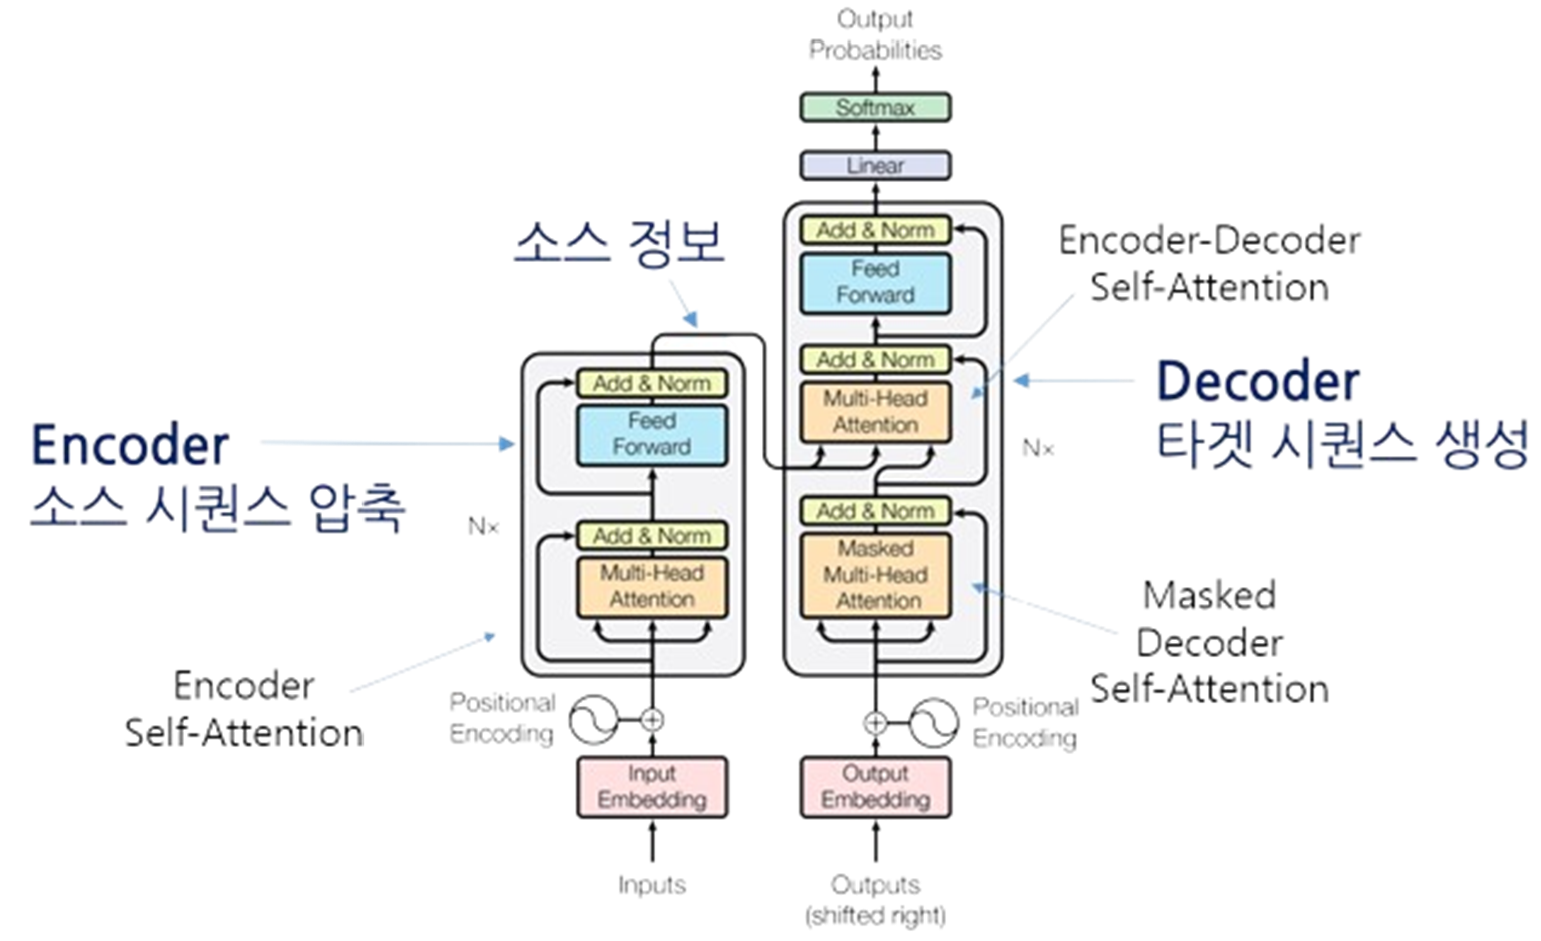

## 2. Transformer 구조

> **Positional Encoding (위치 인코딩)**
> - Self-Attention 기반 모델은 입력 순서를 순차적으로 처리하지 못 함
> - 이에 대해 **<U>토큰 간 순서 정보**</U>를 알려주기 위함 (한 문장을 병렬로 처리하면서도 각 단어의 위치를 인지하게 됨)

> **Encoder Self-Attention**
> - 인코더는 **<U>입력 문장의 모든 단어 간의 관계**</U>를 계산하여, 문장 전체에서 중요한 정보를 파악

> **Add & Norm**
> - 출력에 원래 입력을 **<U>더하고, 값을 정규화**</U>하여 안정된 학습을 도움
> - ResNet - Skip Connection 개념 차용

> **Feed Forward**
> - 활성화 함수(ReLU)를 사용해 입력을 처리해서, 비선형성을 통해 모델이 더 복잡한 패턴을 학습할 수 있게 만드는 **<U>완전 연결 신경망**</U> (쉽게 MLP 떠올리면 됨)

> **Masked Decoder Self-Attention**
> - 디코더가 예측할 때 미래 단어를 **<U>참조하지 못하게 막아**</U>, 이전 단어들만을 사용해 순차적으로 예측

> **Encoder-Decoder Self-Attention**
> - Seq2Seq Attention (Bahdanau/Luong)에서 발전된 형태
> - **<U>디코더가 인코더의 출력을 참조**</U>하여,  입력 문장과의 관계를 기반으로 더 정확한 출력을 생성

## 모델링 개발 방식과 실행 환경 비교

> Open API를 활용하는 방법 vs 직접 AI를 개발하는 방법

| 방법              | 장점                                         | 단점                                             |
| --------------- | ------------------------------------------ | ---------------------------------------------- |
| **Open API 활용** | - 빠른 개발<br>- 비용 절감<br>- 높은 신뢰성             | - 제한된 커스터마이징<br>- 사용량에 따른 비용 증가<br>- 데이터 보안 이슈 |
| **직접 AI 개발**    | - 커스터마이징 가능<br>- 장기적인 비용 절감<br>- 데이터 보안 강화 | - 많은 시간과 전문 지식 필요<br>- 지속적인 유지보수 필요            |

---

> 노코드 모델링 vs 코딩을 활용한 AI 개발

| 방법              | 장점                               | 단점                                 |
| --------------- | -------------------------------- | ---------------------------------- |
| **노코드 모델링**     | - 접근성<br>- 빠른 프로토타이핑<br>- 직관적 사용 | - 제한된 기능<br>- 유연성 부족<br>- 성능 저하 가능 |
| **코딩 활용 AI 개발** | - 유연성<br>- 고성능 모델<br>- 확장성       | - 전문 지식 필요<br>- 시간 소요<br>- 복잡성     |

---

> Make an AI from scratch(zerobase) vs Transfer learning

| 방법                          | 장점                                            | 단점                                  |
| --------------------------- | --------------------------------------------- | ----------------------------------- |
| **Make an AI from scratch** | - 완전한 커스터마이징<br>- 최적화<br>- 모델 이해도             | - 시간·비용 많이 소요<br>- 많은 데이터 필요        |
| **Transfer learning**       | - 시간 절약<br>- 적은 데이터로도 높은 성능<br>- 사전 학습된 모델 활용 | - 제한된 커스터마이징<br>- 적용 범위 제한<br>- 복잡성 |

---

> 웹 서버, 클라우드 환경 vs Edge Computing(on device)

| 방법                 | 장점                                   | 단점                                   |
| ------------------ | ------------------------------------ | ------------------------------------ |
| **웹 서버·클라우드 환경**   | - 확장성<br>- 유지보수 용이<br>- 접근성          | - 비용 증가<br>- 네트워크 지연<br>- 보안 이슈      |
| **Edge Computing** | - 지연 감소<br>- 데이터 보안 강화<br>- 네트워크 독립성 | - 제한된 자원<br>- 개별 관리 필요<br>- 초기 비용 높음 |

---

> Local 환경구축 vs 클라우드기반 환경구축

| 방법               | 장점                                   | 단점                               |
| ---------------- | ------------------------------------ | -------------------------------- |
| **Local 환경구축**   | - 완전한 통제<br>- 보안 강화<br>- 고성능 하드웨어 사용 | - 초기 설치·유지보수 비용 높음<br>- 확장성 제한   |
| **클라우드 기반 환경구축** | - 확장성<br>- 비용 효율성<br>- 접근성           | - 제공자 의존<br>- 보안 이슈<br>- 네트워크 지연 |


## Hugging Face_Transformers 라이브러리 설치하기

- **<U>Colab**</U> : 구글에서 제공하는 클라우드 컴퓨팅 서비스, 주피터 노트북을 기반으로 작동하며, GPU 자원을 무료로 일부 활용할 수 있음

- **<U>Hugging face**</U> : 인공지능 관련 데이터셋, 모델, 테스팅 공간 등을 공유하는 커뮤니티 웹서비스

## NLP(Natural Language Processing) Task 맛보기
- HuggingFace : https://huggingface.co/models
- Tasks : 작업 단위
- Hugging Face Transformers Documents : https://huggingface.co/learn/llm-course/ko/chapter1/3?fw=pt


#### Transformer 종류

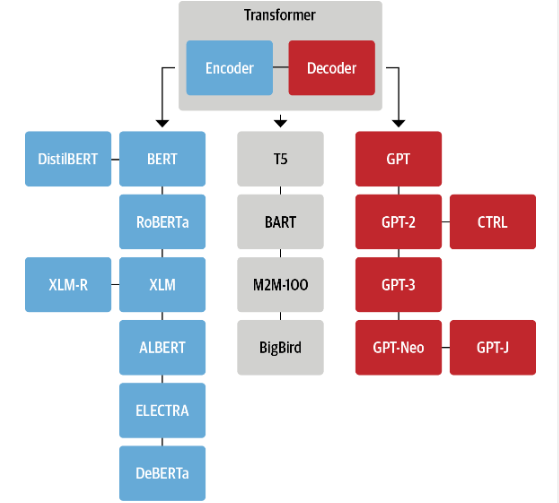

- 넓은 관점에서 트랜스포머 모델은 세 가지로 범주화 할 수 있음

> BERT 계열
> - Transformer 모델의 Encoder만 활용
> - 입력 전체를 한 번에 보고, 양방향으로 학습
> - 대표 모델 : BERT, ELECTRA 등
> - 주 사용처 : 문장 분류, 개체명 인식, 문장 유사도 등 전체 문장에 대한 이해를 요구하는 작업
>     - 빠른 추론과 가벼운 배포가 장점, 분류/검색/추천/임베딩 등 읽기 중심의 task에 많이 쓰임

> Seq2Seq 계열
> - Sequence-to-Sequence(Encoding → Decoding) 구조
> - 다양한 생성, 이해 작업에 강점을 가짐
> - 대표 모델 : T5, BART 등
> - 주 사용처 : 제로샷 분류, 요약/번역/재작성 등
>     - 다수 task(요약, 번역, 생성 등)을 하나의 모델로 운영 할 때 자주 사용

> GPT 계열
> - Transformer 모델의 Decoder만 활용
> - 입력을 순차적으로 처리하며 다음 토큰 예측(순방향)
> - 대표 모델 : GPT, GPT-2, CTRL, GPT-3, GPT-4 등
> - 주 사용처 : 텍스트 생성, 대화형 에이전트 등
>     - 창의적 생성이 장점, 프롬프트 엔지니어링이 중요할 때 선호

### 1. BERT 계열 - 감성분석(sentiment-analysis)
- **<U>Text Classification**</U> : 텍스트를 입력으로 받아 텍스트가 어떤 종류의 범주에 속하는지를 구분하는 작업
- 감성분석(sentiment-analysis) : 텍스트 내에서 사람의 기분, 감정, 의견(Topic) 등을 예측하는 기술

> **KoELECTRA**
> - 한국어에 특화된 ELECTRA 모델
> - 초기 BERT에 비해 학습 효율(속도나 성능) 측면에서 유리하게 만들어짐



```python
# 기존 MLM(Masked Language Modeling) 방식
- 문장에서 일부 단어를 [MASK]로 가린 뒤, 원래 단어를 맞추도록 학습
  → 학습 속도가 느리고, 성능 향상에 더 많은 자원이 필요
```

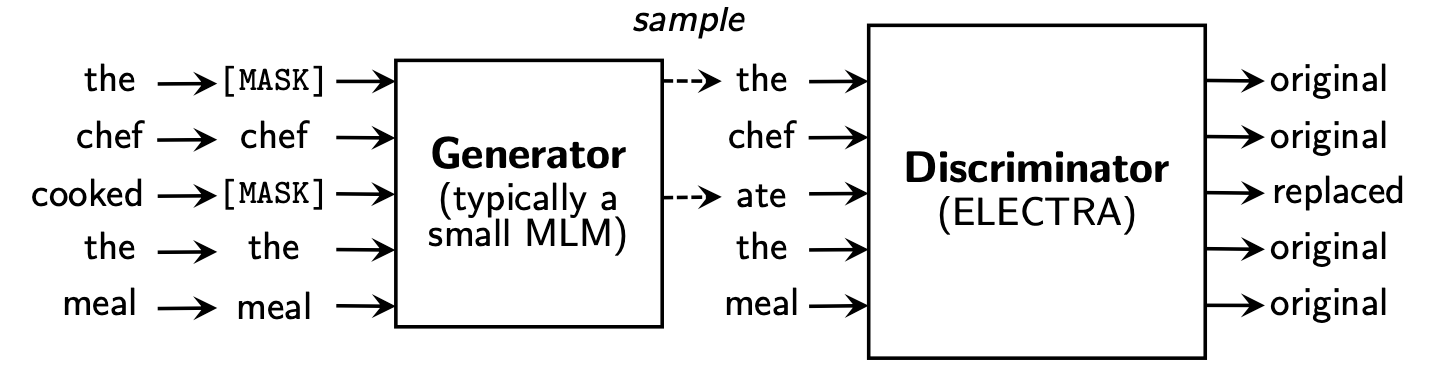

```python
# ELECTRA의 'Replaced Token Detection' 방식
1. 입력 문장 일부 토큰 마스킹
- ex) "the chef cooked the meal" 중 "the"와 "cooked"를 [MASK] 처리

2. Generator (작은 MLM 모델)
- MLM(Masked Language Model) : 전체 문장에서 일부 단어를 마스킹(Masking)하고, 해당 마스킹(Masking)된 단어를 모델의 입력으로
주어졌을 때, 마스킹된 단어를 예측하는 task
- 마스킹된 위치에 원래 토큰인지, 가짜 토큰인지 예측
- ex) [MASK] → "the" / [MASK] → "ate"
- 결과) "the chef ate the meal" (일부 토큰이 대체됨)

3. Discriminator (ELECTRA 본체)
- 각 토큰이 "원본(original)"인지 "대체(replaced)"인지 판별
- ex)
the → original
chef → original
ate → "replaced"
the → original
meal → original

- 작은 '생성기(generator)' 모델이 일부 단어를 가짜 토큰으로 바꿔 넣음
- 큰 '판별기(discriminator)' 모델이 "이 토큰이 원래 단어인가?"를 판별하며 학습
  → 모든 토큰을 검사하므로 학습 신호가 더 많고, 효율이 높음

# ELECTRA는 "가린 단어를 맞추는" 대신 "바뀐 단어를 찾아내는" 학습 방식을 써서 더 빠르고 가성비 좋게 학습 가능
```

- 실습용 사전학습Model 경로 : https://huggingface.co/daekeun-ml/koelectra-small-v3-nsmc
    - daekeun-ml : 일반 사용자(김대근)
    - koelectra-small-v3-nsmc : Naver Sentiment Movie Corpus dataset(네이버 영화 리뷰 데이터셋) 으로 FineTuning 된 KoElectra Model

#### 파이프라인 Task 종류

| 파이프라인                      | 설명                                |
| -------------------------- | --------------------------------- |
| `feature-extraction`       | 특징 추출 (텍스트에 대한 벡터 표현 추출)          |
| `fill-mask`                | 마스크 채우기                           |
| `ner`                      | 개체명 인식 (Named Entity Recognition) |
| `question-answering`       | 질의 응답                             |
| `sentiment-analysis`       | 감정 분석                             |
| `summarization`            | 요약                                |
| `text-generation`          | 텍스트 생성                            |
| `translation`              | 번역                                |
| `zero-shot-classification` | 제로샷 분류 (레이블 분류)                   |


### 2. Seq2Seq 계열 - 문장번역(Translation)

### 3. Zero-shot Classification(제로샷 분류)
- 사전 훈련 된 NLI 모델(Natural Language Inference)을 이용해 새로운 라벨(클래스)에도 별도 학습 없이 분류를 수행하는 Task

> 텍스트에 레이블을 다는 것은 시간이 많이 소요되고 도메인 지식이 필요하기 때문에 이러한 작업은 실제 프로젝트에서 아주 흔한 상황
> - 입력 문장과 후보 라벨(프롬프트로 구성) 간의 연관성을 점수화 하여 가장 적합한 라벨 예측
> - 텍스트 마이닝(ex.추상적인 Topic을 발견)에서도 활용

> 장점
> - 학습 데이터가 없거나 부족한 도메인에서도 즉시 분류 가능
> - 유연하게 라벨을 추가/변경 할 수 있음

> 단점
> - NLI 모델이 다루지 못 하는 복잡한 Task는 성능 저하
> - 라벨 문장(Prompt) 설계에 따라 결과가 민감하게 변동됨

- xlm-roberta-large-xnli `BERT 계열` : 한국어 포함 총 100여 개 언어 지원, 가장 널리 쓰이는 제로샷 분류용 모델 중 하나
- 허깅페이스 링크 : https://huggingface.co/joeddav/xlm-roberta-large-xnli

- 파이프라인을 활용하면 `토크나이징→모델 예측→결과 해석`의 과정을 한 번에 처리 가능
- 허나, 단점도 존재함

| 방식           | 장점                          | 단점                            |
| ------------ | --------------------------- | ----------------------------- |
| **파이프라인**    | - 한 줄로 추론<br>- 자동 전후처리      | - 커스터마이징(ex.Fine Tuning 등) 불가<br>- 배치·학습 불가     |
| **직접 모델 호출** | - 세부 제어 가능<br>- 배치 처리·학습 가능 | - 코드 작성량 증가<br>- 전처리 직접 구현 필요 |


### 4. 직접 모델을 로드해보자
- 4.1) 토크나이저, KoElectra 모델 로드
- 4.2) 인코딩 된 입력을 모델에 전달

> KoElectra 사전학습모델(소형) 링크 : https://huggingface.co/monologg/koelectra-small-finetuned-nsmc
> - monologg 팀(한국어 NLP 엔지니어팀)이 다양한 크기('base', 'small')·버전(v1\~v3)으로 공개
> - nsmc : Naver Sentiment Movie Corpus (네이버 영화 리뷰 데이터)
> - → 이진분류 모델

#### monologg/koelectra 주요 버전 및 종류

- GitHub : https://github.com/monologg/KoELECTRA/blob/master/README.md

| 모델 이름                                       | 크기    | 역할            | 설명                                                         |
| ------------------------------------------- | ----- | ------------- | ---------------------------------------------------------- |
| `monologg/koelectra-base-generator`         | Base  | Generator     | 토큰 생성기(generator) 역할 · v3 이전 버전         |
| `monologg/koelectra-base-discriminator`     | Base  | Discriminator | 토큰 판별기(discriminator) 역할 · v1/v2 기본 버전  |
| `monologg/koelectra-base-v3-generator`      | Base  | Generator     | v3 버전 · generator                       |
| `monologg/koelectra-base-v3-discriminator`  | Base  | Discriminator | v3 버전 · discriminator                   |
| `monologg/koelectra-small-generator`        | Small | Generator     | 소형 모델 · generator                       |
| `monologg/koelectra-small-discriminator`    | Small | Discriminator | 소형 모델 · discriminator                   |
| `monologg/koelectra-small-v3-generator`     | Small | Generator     | v3 소형 버전 · generator (NSMC 감성분석 등에 활용 가능)                  |
| `monologg/koelectra-small-v3-discriminator` | Small | Discriminator | v3 소형 버전 · discriminator (감정분석, 문장분류 등)                    |
| `monologg/koelectra-small-v3-goemotions`    | Small | Discriminator | v3 소형 버전 · GoEmotions 감정분류용 (영문 감정 레이블 매핑)                 |
| `monologg/koelectra-base-v3-naver-ner`      | Base  | Discriminator | v3 버전 · Naver NER(개체명 인식)용 fine-tuned 모델                   |
| `monologg/koelectra-base-v3-gender-bias`    | Base  | Discriminator | v3 버전 · 성별 편향 분석용 (gender-bias) 모델                         |

> ※ Generator는 ELECTRA 학습 시 가짜 토큰을 만드는 역할, Discriminator는 가짜 vs 진짜 토큰을 구분하는 역할을 수행

##### 4.1) 토크나이저, KoElectra 모델 로드


```python
# Load model directly (모델 직접 로드)
from transformers import AutoTokenizer, AutoModelForSequenceClassification
# AutoTokenizer: 다양한 사전학습 토크나이저를 자동으로 로드해주는 클래스
# AutoModelForSequenceClassification: 시퀀스 분류용(pretrained) 모델을 자동으로 로드해주는 클래스

# Hugging Face Hub에 등록된 사전학습 토크나이저를 불러옴
# 한국어 KoELECTRA-base를 NSMC 감성분석으로 파인튜닝한 토크나이저
tokenizer = AutoTokenizer.from_pretrained("monologg/koelectra-base-finetuned-nsmc")

# 시퀀스 분류(감성분석 등)용 사전학습 모델 가중치를 로드
# 토크나이저와 동일한 NSMC 파인튜닝된 KoELECTRA-base 모델
model = AutoModelForSequenceClassification.from_pretrained("monologg/koelectra-base-finetuned-nsmc")
```

##### 4.2) 인코딩 된 입력을 모델에 전달

- config 설명

| 속성                             | 설명                                                        |
| ------------------------------ | --------------------------------------------------------- |
| `model_type`                   | 모델 유형 (`"electra"`)                                       |
| `architectures`                | 로드된 모델 클래스 이름 (`["ElectraForSequenceClassification"]`)    |
| `vocab_size`                   | 어휘 사전 크기 (토크나이저가 사용하는 토큰 개수)                              |
| `embedding_size`               | 임베딩 차원 수 (토큰 임베딩 벡터의 크기)                                  |
| `hidden_size`                  | Transformer 블록 내부 피처 차원 수                                 |
| `num_hidden_layers`            | 인코더(혹은 디코더) 레이어 개수                                        |
| `num_attention_heads`          | 어텐션 헤드 수                                                  |
| `intermediate_size`            | Feed-Forward 네트워크의 은닉층 차원 수                               |
| `hidden_act`                   | 은닉층 활성화 함수 (`"gelu"`)                                     |
| `layer_norm_eps`               | LayerNorm 안정화를 위한 작은 값                                    |
| `position_embedding_type`      | 위치 임베딩 방식 (`"absolute"`)                                  |
| `max_position_embeddings`      | 시퀀스 길이 최대값 (위치 임베딩 개수)                                    |
| `type_vocab_size`              | 세그먼트(토큰 타입) 임베딩 크기                                        |
| `pad_token_id`                 | 패딩 토큰 ID                                                  |
| `use_cache`                    | 디코더에서 이전 키·값 캐싱 사용 여부                                     |
|                                |                                                           |
| **드롭아웃 관련**                    |                                                           |
| `attention_probs_dropout_prob` | 어텐션 확률 드롭아웃 비율                                            |
| `hidden_dropout_prob`          | 은닉층 드롭아웃 비율                                               |
| `classifier_dropout`           | 분류기 헤드 드롭아웃 비율 (여기선 `null` → 기본 `hidden_dropout_prob` 사용) |
|                                |                                                           |
| **레이블 매핑**                     |                                                           |
| `id2label`                     | 예측된 정수 레이블을 문자열로 매핑 (`0→"negative"`, `1→"positive"`)      |
| `label2id`                     | 문자열 레이블을 정수로 매핑 (`"negative"→0`, `"positive"→1`)          |
|                                |                                                           |
| **기타**                         |                                                           |
| `initializer_range`            | 가중치 초기화 시 표준편차                                            |
| `finetuning_task`              | 파인튜닝 목적 태스크 이름 (`"nsmc"`)                                 |
| `torch_dtype`                  | 모델 내부 연산에 사용하는 텐서 자료형 (`"float32"`)                       |
| `transformers_version`         | 이 설정을 만든 Transformers 라이브러리 버전                            |


- 확률로 변환해 보기

### 5. Transformers 라이브러리의 구성 요소 (정리)

| 구성요소                    | 설명                                                                                                                                                                                                                |
| ----------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Config 객체**           | - 모델 아키텍처 설정 정보 저장 (예: hidden\_size=768, num\_layers=12)<br>- `AutoConfig.from_pretrained(model_name)` 또는 `model.config`로 접근                                                                                      |
| **Tokenizer**           | - 문자열 ↔ 토큰 시퀀스 변환 모듈 (WordPiece, BPE 등)<br>- `AutoTokenizer`가 모델에 맞는 클래스 자동 선택<br>- `tokenizer.encode`/`__call__`로 ID 시퀀스 생성, `decode`로 복원                                                                        |
| **Model & AutoModel**   | - 사전학습 모델 구조와 가중치 로드 클래스 (예: `BertModel`, `GPT2Model`)<br>- `AutoModel.from_pretrained(model_name)`으로 적절한 모델 자동 선택                                                                                                |
| **Task-specific Model** | - 특정 태스크용 헤드(head) 포함 모델<br>- 분류: `AutoModelForSequenceClassification`<br>- QA: `AutoModelForQuestionAnswering` 등<br>- 예: `AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)` |
| **Pipeline**            | - 토크나이저 + 모델 + 후처리를 한 번에 묶은 고수준 인터페이스<br>- `pipeline("sentiment-analysis")` 등으로 바로 예측 결과(라벨·점수) 반환                                                                                                                |
| **Trainer**             | - 학습 루프·평가·체크포인트 저장·로깅 등을 캡슐화한 고수준 API<br>- 별도 학습 코드 없이도 파인튜닝 가능<br>- 옵티마이저·스케줄러 설정, 평가 지표 출력 등 지원                                                                                                                |
